In [2]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\Pradi\anaconda3\envs\python_subject\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
## Skill count per month for data engineer
df_DE_US = df[(df['job_title'] == 'Data Engineer') & (df['job_country'] == 'United States')].copy()

df_DE_US['job_posted_month_no'] = df_DE_US['job_posted_date'].dt.month

# Explode job_skills column
df_DE_US_explode = df_DE_US.explode('job_skills')

In [4]:
# Group by month and job_skills
pivot = df_DE_US_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

In [5]:
# sorts by count
pivot.loc['Total'] = pivot.sum()
df_DE_US_pivot = pivot[pivot.loc['Total'].sort_values(ascending=False).index]
pivot = pivot.drop('Total')

pivot

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,visual basic,vmware,vue,vue.js,watson,windows,wire,word,yarn,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,84,0,10,5,1,7,0,0,0,2,...,5,2,0,0,0,11,0,9,3,0
2,100,1,16,6,0,9,0,0,1,4,...,2,1,2,0,0,22,0,18,6,2
3,104,0,21,4,2,14,0,0,0,2,...,0,1,0,0,0,10,0,18,2,1
4,106,2,14,8,0,12,0,0,0,1,...,1,0,2,0,1,10,0,14,2,0
5,130,0,17,16,0,6,0,1,2,1,...,10,1,5,1,0,21,0,12,0,2
6,115,0,28,5,0,12,0,0,3,0,...,0,2,0,0,0,13,0,16,0,2
7,93,2,22,3,0,10,0,0,0,1,...,1,1,1,0,0,21,0,8,0,3
8,143,0,16,8,1,8,1,0,2,1,...,0,0,1,0,1,19,1,11,1,2
9,118,0,11,6,0,17,0,0,0,1,...,2,2,0,1,0,14,1,25,2,2


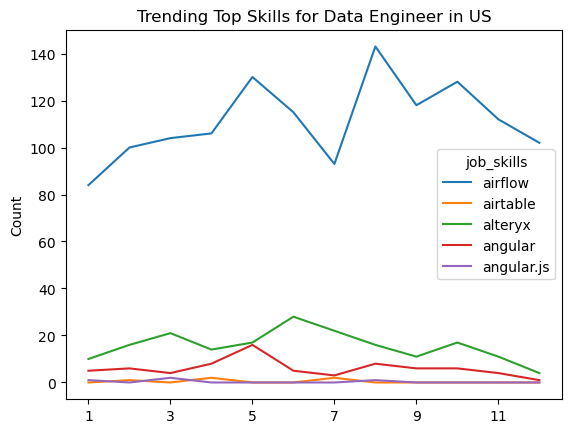

In [6]:
pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Data Engineer in US')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [7]:
# Get monthly totals
DA_totals = df_DE_US.groupby('job_posted_month_no').size()

DA_totals

job_posted_month_no
1     700
2     860
3     862
4     726
5     789
6     824
7     655
8     833
9     863
10    837
11    794
12    666
dtype: int64

In [8]:
# divide first 12 rows of df_DA_pivot by DA_totals
df_DE_US_percent = pivot.iloc[:12].div(DA_totals/100, axis=0)

# changes month number to month name
df_DE_US_percent = df_DE_US_percent.reset_index()
df_DE_US_percent['job_posted_month'] = df_DE_US_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DE_US_percent = df_DE_US_percent.set_index('job_posted_month')
df_DE_US_percent = df_DE_US_percent.drop(columns='job_posted_month_no')

df_DE_US_percent

job_skills,airflow,airtable,alteryx,angular,angular.js,ansible,apl,arch,asana,asp.net,...,visual basic,vmware,vue,vue.js,watson,windows,wire,word,yarn,zoom
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,12.000000,0.000000,1.428571,0.714286,0.142857,1.000000,0.000000,0.000000,0.000000,0.285714,...,0.714286,0.285714,0.000000,0.000000,0.000000,1.571429,0.000000,1.285714,0.428571,0.000000
Feb,11.627907,0.116279,1.860465,0.697674,0.000000,1.046512,0.000000,0.000000,0.116279,0.465116,...,0.232558,0.116279,0.232558,0.000000,0.000000,2.558140,0.000000,2.093023,0.697674,0.232558
Mar,12.064965,0.000000,2.436195,0.464037,0.232019,1.624130,0.000000,0.000000,0.000000,0.232019,...,0.000000,0.116009,0.000000,0.000000,0.000000,1.160093,0.000000,2.088167,0.232019,0.116009
Apr,14.600551,0.275482,1.928375,1.101928,0.000000,1.652893,0.000000,0.000000,0.000000,0.137741,...,0.137741,0.000000,0.275482,0.000000,0.137741,1.377410,0.000000,1.928375,0.275482,0.000000
May,16.476553,0.000000,2.154626,2.027883,0.000000,0.760456,0.000000,0.126743,0.253485,0.126743,...,1.267427,0.126743,0.633714,0.126743,0.000000,2.661597,0.000000,1.520913,0.000000,0.253485
Jun,13.956311,0.000000,3.398058,0.606796,0.000000,1.456311,0.000000,0.000000,0.364078,0.000000,...,0.000000,0.242718,0.000000,0.000000,0.000000,1.577670,0.000000,1.941748,0.000000,0.242718
Jul,14.198473,0.305344,3.358779,0.458015,0.000000,1.526718,0.000000,0.000000,0.000000,0.152672,...,0.152672,0.152672,0.152672,0.000000,0.000000,3.206107,0.000000,1.221374,0.000000,0.458015
Aug,17.166867,0.000000,1.920768,0.960384,0.120048,0.960384,0.120048,0.000000,0.240096,0.120048,...,0.000000,0.000000,0.120048,0.000000,0.120048,2.280912,0.120048,1.320528,0.120048,0.240096
Sep,13.673233,0.000000,1.274623,0.695249,0.000000,1.969873,0.000000,0.000000,0.000000,0.115875,...,0.231750,0.231750,0.000000,0.115875,0.000000,1.622248,0.115875,2.896871,0.231750,0.231750


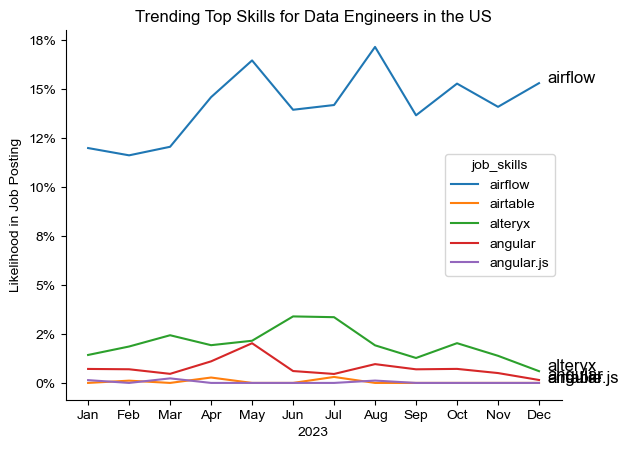

In [9]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DE_US_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() # remove top and right spines

plt.title('Trending Top Skills for Data Engineers in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()